In [24]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [25]:
# =========================================================
# 2. LOAD DATASET
# =========================================================
df = pd.read_csv("lastdata.csv")


In [26]:
# =========================================================
# 3. DATA EXPLORATION
# =========================================================
print("\n================ FIRST 5 ROWS ================\n")
print(df.head())

print("\n================ DATA INFO ================\n")
print(df.info())


================ FIRST 5 ROWS ================

                                                text           category
0  SULDAAN SACIID AXMED Suldaan Saciid Axmed oo a...  not crime-related
1  Nin isku dayay inuu dad ka badbaadiyo diyaarad...  not crime-related
2  Cilmi-baadhis cusub ayaa soo jeedisay in guurk...  not crime-related
3  Sacuudi Carabiya ayaa ku dhawaaqday inay baasa...  not crime-related
4  Labada madaxweyne ee Soomaaliya iyo Turkiga Xs...  not crime-related

================ DATA INFO ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      9997 non-null   object
 1   category  9999 non-null   object
dtypes: object(2)
memory usage: 156.4+ KB
None


In [27]:
# =========================================================
# 4. RENAME COLUMNS
# =========================================================
# Dataset columns:
# first column  -> text
# second column -> label

df.columns = ['text', 'label']

In [28]:
# =========================================================
# 5. CLEAN LABELS
# =========================================================
df['label'] = df['label'].astype(str)

df['label'] = df['label'].str.lower()

df['label'] = df['label'].str.strip()

# Fix inconsistent labels
df['label'] = df['label'].replace({

    'crime related': 'crime-related',
    'not crime related': 'not crime-related',
    'crime': 'crime-related',
    'not crime': 'not crime-related'

})

print("\n================ UNIQUE LABELS ================\n")
print(df['label'].unique())

print("\n================ LABEL COUNTS ================\n")
print(df['label'].value_counts())


================ UNIQUE LABELS ================

['not crime-related' 'crime-related']

================ LABEL COUNTS ================

label
not crime-related    5000
crime-related        4999
Name: count, dtype: int64


In [29]:
# =========================================================
# 6. MISSING VALUES
# =========================================================
print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())
# Remove missing values
df = df.dropna()


================ MISSING VALUES ================

text     2
label    0
dtype: int64



================ DUPLICATES ================

1315


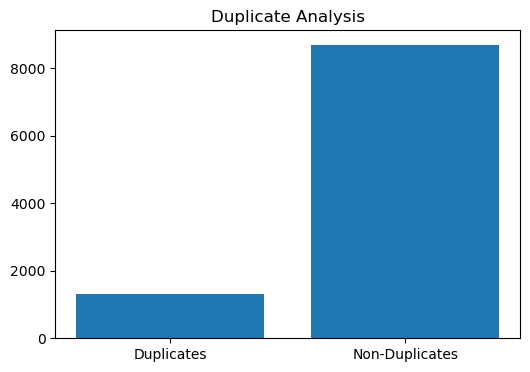

In [30]:
# =========================================================
# 7. DUPLICATE ANALYSIS
# =========================================================
duplicates = df.duplicated().sum()

print("\n================ DUPLICATES ================\n")
print(duplicates)

# Duplicate chart
plt.figure(figsize=(6,4))

plt.bar(
    ['Duplicates', 'Non-Duplicates'],
    [duplicates, len(df)-duplicates]
)

plt.title("Duplicate Analysis")

plt.show()

# Remove duplicates
df = df.drop_duplicates()


In [31]:
# =========================================================
# 8. SOMALI STOPWORDS
# =========================================================
somali_stopwords = ['waa','iyo','ka','ku','ah','la','uu','ay','oo','in','aan','u','wax','marka','ama','hadda',
                    'kasoo','kale','haddii','inta','lagu','si','hadana','wuxuu','waxaa','iyada','iyadoo','markii',
                    'sidoo','kuwa','waxay','qof','dadka','ayaa','taan','kaddib','jirta','kuwaas','dhan','waana',
                    'isagoo','ee','waxey','mid','Mid','lasoo','ugu','waxa','eeyga','loo','sii','Haddaba','loona',
                    'inkastoo','kula','waxuu','uga','soo','kuu','eey','aad','baan','leh','beey','ahna','yahay',
                    'mana','waxaana','sida','dib','maxay','inay','inaan','inaana','inaanay','inaaney','lakin',
                    'inuu','hadana','ayuu','aaney','ayee','kala','kule','kalena','aysan','laakiin','hor','ayay',
                    'wali','isku','halkaasoo','kuna','isla','markaana','ahaanba','kamid','kaasoo','Guud','intaas',
                    'Muxuu','awgeed','miyuu','iska','kaliya','markiiba','Kuwo','Kuwa','intaysan','wuxuuna','xitaa',
                    'kuwee','kuwii','intii','intaa','dabadeed','yihiin','gabi','iskaba','awgii','isugu','kuwaasoo',
                    'kaddibna','waxba','usoo','lagama','wuu','lamana','naga','loogu','aadka','kii','kana','idiin',
                    'inoo','aynu','yaa','iney','waxaan','waliba','kasta','ilaa','ahayd','waxana','ina','inan',
                    'waxaas', 'maxaad','wixii', 'uusan', 'walba', 'ahayn','inaga','kuwo','ila', 'wada', 'una',
                    'xataa','walina','way','inaad','kama','ahaa','lama','kaga','kaas','nagu','aay','ha','aaynu',
                    'uma','ayaad','kusoo','aha','sidee','iskugu','kalana','kamida','hore','inkasta','iwm','waxayna',
                    'hase','maxaan','ayaana','kahor','kadib','kaa','aheyn','kugu','waxaanu','kan','ayey','kaasi',
                    'noo','iga','iigu','ayayna','inuusan','baannu','looga','idin','kadibna','ahaatee','waaye',
                    'nooga','isu','kaleba','maxaa','islamarkaana','lagala','wuxi','kastaba','naloo','walbo','kuma',
                    'is','mise','igu','lakiin', 'baa', 'yaan', 'nagala', 'amase', 'haa', 'waxaad', 'idiinku',
                    'maxad','kasii','baad','waxan','sidii','kuwaasi','iskeed','ula','nugul','horta','intiisa',
                    'yeeshee','kusii','uugu','sideen','unbuu','looguna','inaanu','markuu','bal','mooyee','hadduu',
                    'midba','wuxu','waayo','iima','iimaanu','waxsoo','laga','innoo','aanad','lala','amma','waad',
                    'kuugu','hadii','markaa','hasii','lee','anaan','ii','tankale','weeyaan','waase','isoo','haatan',
                    'haddana','waxaanay','ayna','uuna','inaysan','aya','laguna','laguma','ta','inaa','lkn','haku',
                    'hasoo','waayahay','kulasoo','laakin','sidaas','sheegay'
]


In [32]:
# =========================================================
# 9. TEXT CLEANING FUNCTION
# =========================================================
def clean_text(text):

    # convert to string
    text = str(text)

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # remove mentions
    text = re.sub(r'@\w+', '', text)

    # remove hashtags
    text = re.sub(r'#\w+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)
     # remove punctuation/noise
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_text)


In [33]:
# =========================================================
# 10. REMOVE STOPWORDS
# =========================================================
def remove_stopwords(text):

    words = text.split()

    filtered_words = [

        word for word in words
        if word not in somali_stopwords

    ]

    return " ".join(filtered_words)

df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)

In [34]:
# =========================================================
# 11. REMOVE EMPTY TEXT
# =========================================================
df = df[df['cleaned_text'].str.strip() != '']

print("\n================ DATASET SIZE AFTER CLEANING ================\n")
print(df.shape)


================ DATASET SIZE AFTER CLEANING ================

(8681, 3)


In [35]:
# =========================================================
# 12. BEFORE vs AFTER CLEANING
# =========================================================
print("\n================ BEFORE CLEANING ================\n")
print(df['text'].iloc[0])

print("\n================ AFTER CLEANING ================\n")
print(df['cleaned_text'].iloc[0])



================ BEFORE CLEANING ================

SULDAAN SACIID AXMED Suldaan Saciid Axmed oo ah Soomaaligii ugu horreeyay ee ka mid noqda baarlamaanka dalka Finland ayaa loo heystaa arrin la xiriirta takaasida uu isticmaalo. Suldaan oo xubin ka ah Xisbiga Isbahaysiga Bidix ayaa ballan-qaaday inuu dib u bixin doono dhammaanba kharashka takaasida uu u isticmaalay wax ka baxsan waajibaadkiisa xildhibaannimo. Arrintan ayaa timid kaddib markii wargeyska Iltalehti ee ka soo baxa dalka Finland uu isbarbardhig ku sameeyay taksiyada ay isticmaaleen xildhibaannada baarlamaanka laga soo billaabo bilihii ilaa Maarsadii sanadkan, wuxuuna ogaaday in kharashka uu isticmaalay Suldaan uu yahay kan ugu badan. Wargeyska ayaa sidoo kale ogaaday in baarlamaanka Finland uu Suldaan u oggolaaday inuu isticmaalo taksi, sababo la xiriira ammaankiisa. Wuxuu sheegay in sirdoonka Finland iyo waaxda ammaanka ee baarlamaanka dalkaas ay sameeyeen qiimeyn ku saabsan ammaankiisa isla markaana ay ogaadeen in ammaank

In [36]:
# =========================================================
# 13. TEXT ANALYSIS
# =========================================================

# Sentence length
df['sentence_length'] = df['cleaned_text'].apply(len)

# Word count
df['word_count'] = df['cleaned_text'].apply(
    lambda x: len(x.split())
)

print("\n================ AVG SENTENCE LENGTH ================\n")
print(df.groupby('label')['sentence_length'].mean())

print("\n================ AVG WORD COUNT ================\n")
print(df.groupby('label')['word_count'].mean())


================ AVG SENTENCE LENGTH ================

label
crime-related         870.225614
not crime-related    1533.621868
Name: sentence_length, dtype: float64

================ AVG WORD COUNT ================

label
crime-related        109.903485
not crime-related    194.316284
Name: word_count, dtype: float64


In [37]:
# =========================================================
# 14. LABEL ENCODING
# =========================================================
df['label_encoded'] = df['label'].map({

    'crime-related': 1,
    'not crime-related': 0

})

# Remove invalid labels
df = df.dropna(subset=['label_encoded'])

# Convert to integer
df['label_encoded'] = df['label_encoded'].astype(int)

print("\n================ ENCODED LABELS ================\n")
print(df['label_encoded'].value_counts())


================ ENCODED LABELS ================

label_encoded
1    4849
0    3832
Name: count, dtype: int64


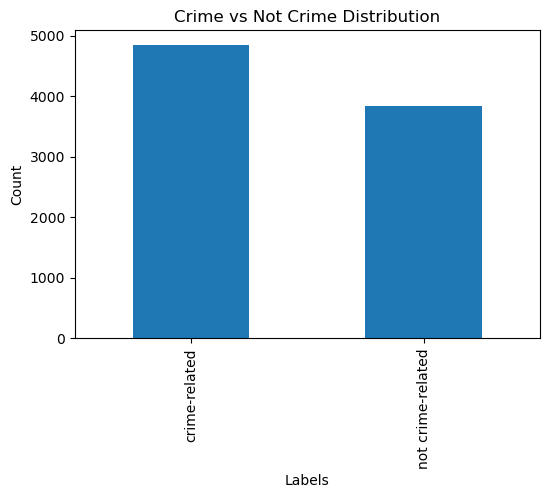

In [38]:
# =========================================================
# 15. LABEL DISTRIBUTION CHART
# =========================================================
plt.figure(figsize=(6,4))

df['label'].value_counts().plot(kind='bar')

plt.title("Crime vs Not Crime Distribution")
plt.xlabel("Labels")
plt.ylabel("Count")

plt.show()

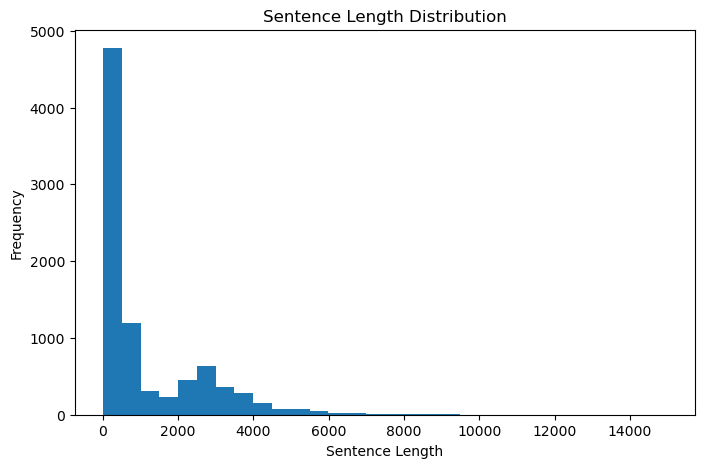

In [39]:
# =========================================================
# 16. SENTENCE LENGTH HISTOGRAM
# =========================================================
plt.figure(figsize=(8,5))

df['sentence_length'].plot.hist(bins=30)

plt.title("Sentence Length Distribution")
plt.xlabel("Sentence Length")

plt.show()

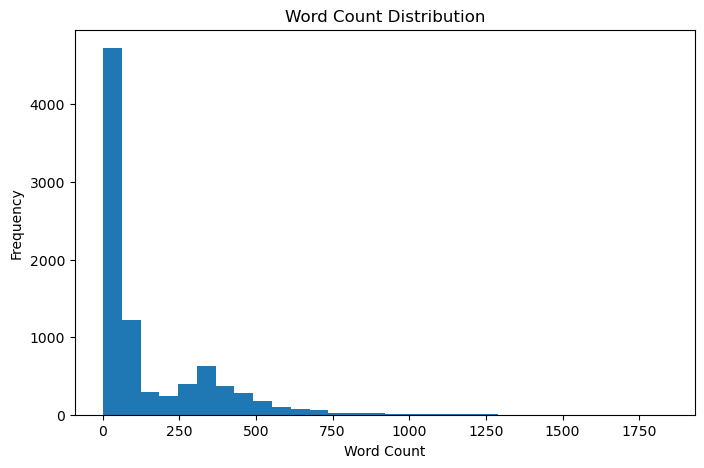

In [40]:
# =========================================================
# 17. WORD COUNT HISTOGRAM
# =========================================================
plt.figure(figsize=(8,5))

df['word_count'].plot.hist(bins=30)

plt.title("Word Count Distribution")
plt.xlabel("Word Count")

plt.show()

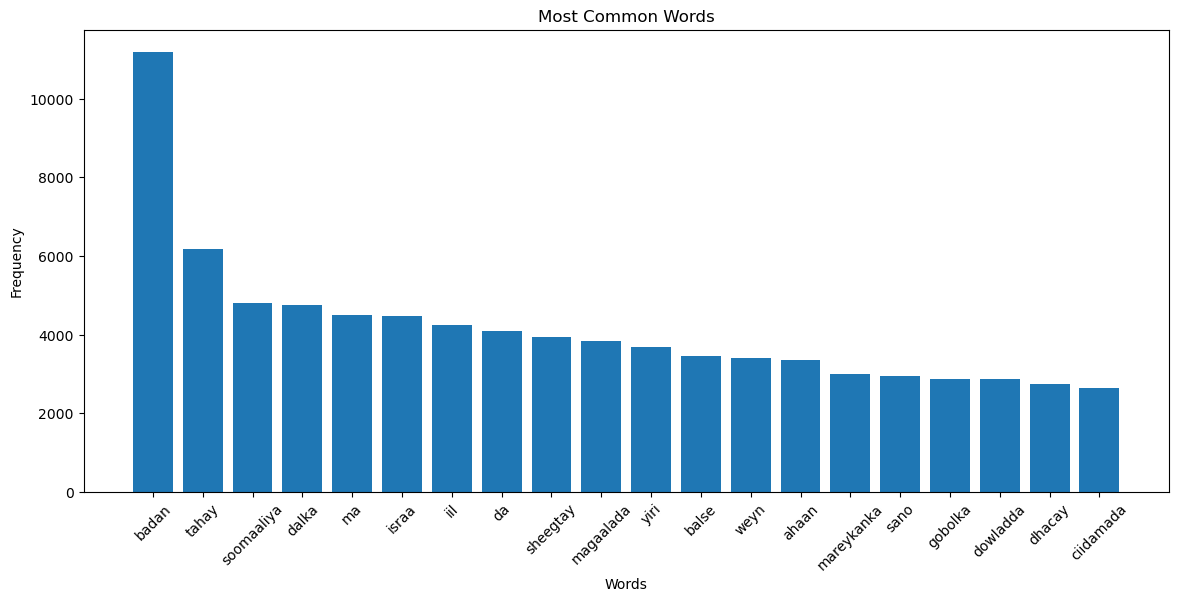

In [41]:
# =========================================================
# 18. WORD FREQUENCY ANALYSIS
# =========================================================
all_words = " ".join(df['cleaned_text']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]

counts = [w[1] for w in common_words]

# Word frequency chart
plt.figure(figsize=(14,6))

plt.bar(words, counts)

plt.title("Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [42]:
# =========================================================
# 19. LONGEST SENTENCES
# =========================================================
longest_sentences = df.sort_values(
    by='sentence_length',
    ascending=False
)[['cleaned_text', 'sentence_length']].head(10)

print("\n================ LONGEST SENTENCES ================\n")
print(longest_sentences)


================ LONGEST SENTENCES ================

                                           cleaned_text  sentence_length
3840  wararkii dambeeyay dagaal beeleed dad badan dh...            14971
3619  itoobiya ma noqon kartaa aqoonsigii madax bann...            12349
9172  javier gallardo jecel subaxdiisa bilaabo daawa...            11687
3667  naqaan taariikhda boqortooyada faca weyn ajuur...            11116
8534  toos israaiil cirka duqeynaysa bayruut tehran ...            10135
8296  yaab ninkii walaalkeey dilay ayaan sano facebo...             9680
8500  duqeymo cusub iran gobolka jiro sacuudi carabi...             9641
3948  abwaan axmed saleebaan bidde qisadii jacaylka ...             9214
4445  horyaalka premier league liverpool ma ilaashan...             9207
1131  safarkaygii baariis magaaladii helay aniga teg...             9044


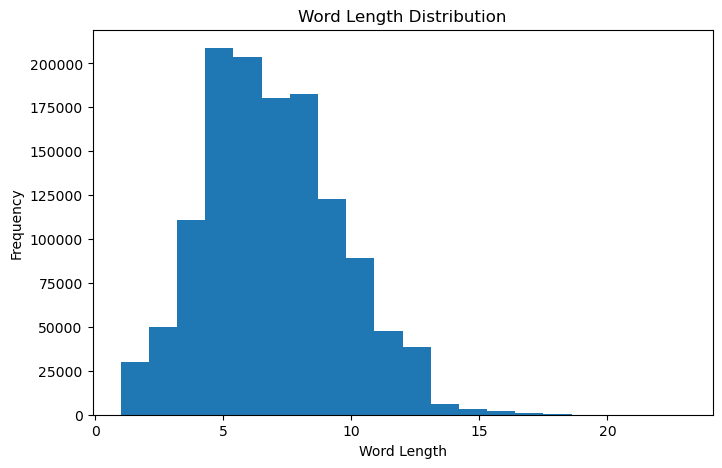

In [43]:
# =========================================================
# 20. WORD LENGTH DISTRIBUTION
# =========================================================
word_lengths = [len(word) for word in all_words]

plt.figure(figsize=(8,5))

plt.hist(word_lengths, bins=20)

plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.show()

In [44]:
# =========================================================
# 21. MOST REPEATED WORDS
# =========================================================
print("\n================ MOST REPEATED WORDS ================\n")
print(word_freq.most_common(20))

# =========================================================
# 22. TF-IDF FEATURE EXTRACTION
# =========================================================
vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(df['cleaned_text'])

y = df['label_encoded']


================ MOST REPEATED WORDS ================

[('badan', 11188), ('tahay', 6167), ('soomaaliya', 4812), ('dalka', 4742), ('ma', 4506), ('israa', 4461), ('iil', 4246), ('da', 4089), ('sheegtay', 3937), ('magaalada', 3828), ('yiri', 3686), ('balse', 3468), ('weyn', 3399), ('ahaan', 3361), ('mareykanka', 3002), ('sano', 2941), ('gobolka', 2873), ('dowladda', 2867), ('dhacay', 2734), ('ciidamada', 2643)]


In [45]:
# =========================================================
# 23. TRAIN TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)


In [46]:
# =========================================================
# 24. MACHINE LEARNING MODELS
# =========================================================
# =========================================================
# MACHINE LEARNING MODELS
# =========================================================
models = {

    'Logistic Regression':
        LogisticRegression(max_iter=1000),

    'Random Forest':
        RandomForestClassifier(),

    'Decision Tree':
        DecisionTreeClassifier(),

    'Naive Bayes':
        MultinomialNB(),

    'KNN':
        KNeighborsClassifier(),

    'SVM':
        SVC(kernel='linear'),

    'Neural Network':
        MLPClassifier(max_iter=1000)

}

In [47]:
# =========================================================
# 25. TRAIN & EVALUATE
# =========================================================
results = []

for name, model in models.items():

    print("\n================================================")

    print(f"TRAINING: {name}")

    print("================================================")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Save results
    results.append([

        name,
        accuracy,
        precision,
        recall,
        f1

    ])

    # Print metrics
    print("\nAccuracy :", round(accuracy, 4))

    print("Precision:", round(precision, 4))

    print("Recall   :", round(recall, 4))

    print("F1 Score :", round(f1, 4))
    
    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))


TRAINING: Logistic Regression

Accuracy : 0.8889
Precision: 0.8928
Recall   : 0.9103
F1 Score : 0.9015

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       767
           1       0.89      0.91      0.90       970

    accuracy                           0.89      1737
   macro avg       0.89      0.89      0.89      1737
weighted avg       0.89      0.89      0.89      1737


TRAINING: Random Forest

Accuracy : 0.9223
Precision: 0.913
Recall   : 0.9515
F1 Score : 0.9319

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       767
           1       0.91      0.95      0.93       970

    accuracy                           0.92      1737
   macro avg       0.92      0.92      0.92      1737
weighted avg       0.92      0.92      0.92      1737


TRAINING: Decision Tree

Accuracy : 0.878
Precision: 0.8891
Recall   : 0.8928
F1 Score : 0.890

In [48]:
# =========================================================
# 26. FINAL RESULTS TABLE
# =========================================================
results_df = pd.DataFrame(

    results,

    columns=[

        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'

    ]

)

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)
print("\n================ FINAL RESULTS ================\n")

print(results_df)


================ FINAL RESULTS ================

                 Model  Accuracy  Precision    Recall  F1 Score
1        Random Forest  0.922280   0.912957  0.951546  0.931853
5                  SVM  0.904433   0.906883  0.923711  0.915220
6       Neural Network  0.892343   0.911672  0.893814  0.902655
0  Logistic Regression  0.888889   0.892821  0.910309  0.901480
3          Naive Bayes  0.879102   0.867505  0.924742  0.895210
2        Decision Tree  0.877950   0.889117  0.892784  0.890947
4                  KNN  0.552677   0.961722  0.207216  0.340967


<Figure size 1200x600 with 0 Axes>

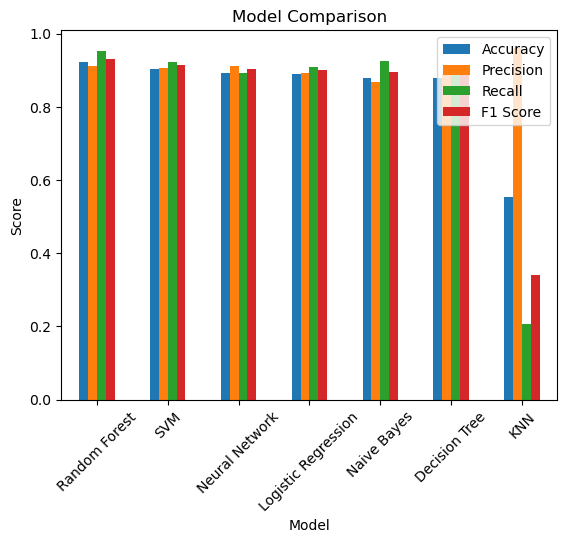

In [49]:
# =========================================================
# 27. MODEL COMPARISON CHART
# =========================================================
plt.figure(figsize=(12,6))

results_df.plot(

    x='Model',

    y=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    kind='bar'

)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=45)
plt.show()

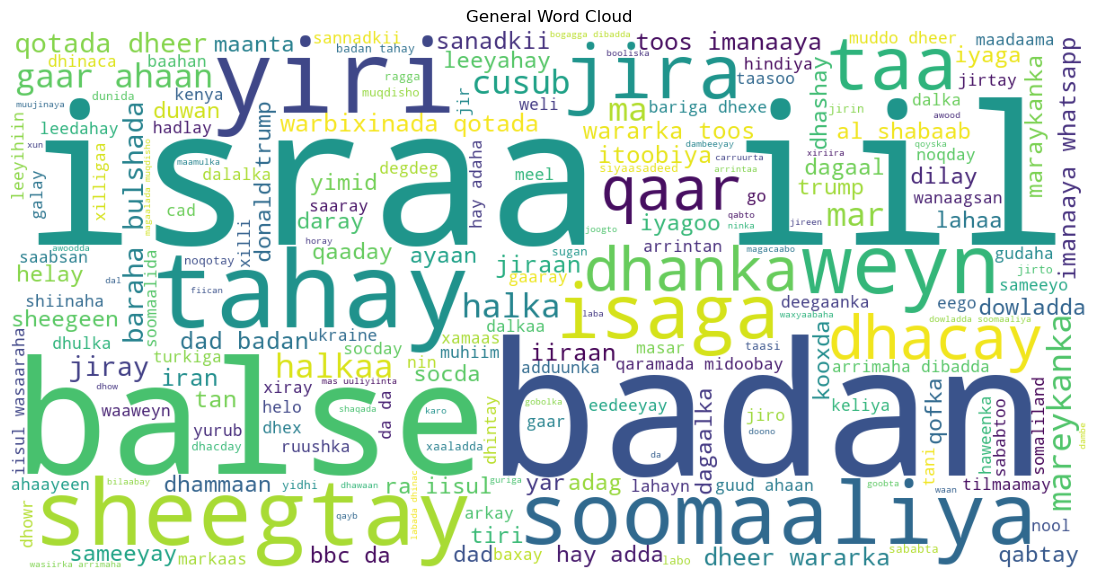

In [50]:
# =========================================================
# 28. WORD CLOUD
# =========================================================
wordcloud = WordCloud(

    width=1200,
    height=600,
    background_color='white'

).generate(" ".join(all_words))

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("General Word Cloud")

plt.show()

In [51]:
# =========================================================
# 29. LABEL-BASED ANALYSIS
# =========================================================
crime_df = df[df['label'] == 'crime-related']

notcrime_df = df[df['label'] == 'not crime-related']

print("\n================ CRIME ANALYSIS ================\n")

print("Average Sentence Length:")
print(crime_df['sentence_length'].mean())

print("\nAverage Word Count:")
print(crime_df['word_count'].mean())

print("\n================ NOT CRIME ANALYSIS ================\n")

print("Average Sentence Length:")
print(notcrime_df['sentence_length'].mean())

print("\nAverage Word Count:")
print(notcrime_df['word_count'].mean())


================ CRIME ANALYSIS ================

Average Sentence Length:
870.2256135285626

Average Word Count:
109.90348525469169

================ NOT CRIME ANALYSIS ================

Average Sentence Length:
1533.6218684759917

Average Word Count:
194.31628392484342


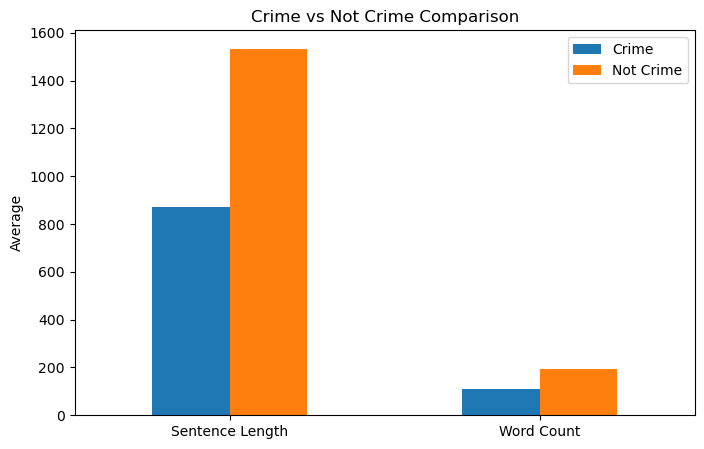

In [52]:
# =========================================================
# 30. COMPARISON CHART
# =========================================================
comparison = pd.DataFrame({

    'Crime': [

        crime_df['sentence_length'].mean(),
        crime_df['word_count'].mean()

    ],

    'Not Crime': [

        notcrime_df['sentence_length'].mean(),
        notcrime_df['word_count'].mean()

    ]

},
index=[

    'Sentence Length',
    'Word Count'

])

comparison.plot(kind='bar', figsize=(8,5))

plt.title("Crime vs Not Crime Comparison")

plt.ylabel("Average")

plt.xticks(rotation=0)

plt.show()
                          

In [53]:

# =========================================================
# 31. TOP WORDS IN CRIME POSTS
# =========================================================
crime_words = " ".join(
    crime_df['cleaned_text']
).split()

crime_common = Counter(crime_words).most_common(10)

print("\n================ TOP CRIME WORDS ================\n")

print(crime_common)


================ TOP CRIME WORDS ================

[('badan', 3789), ('israa', 3662), ('iil', 3467), ('dalka', 2192), ('magaalada', 2174), ('ciidamada', 2090), ('sheegtay', 1919), ('dilay', 1905), ('dhacay', 1856), ('tahay', 1816)]


In [54]:
# =========================================================
# 32. TOP WORDS IN NOT CRIME POSTS
# =========================================================
notcrime_words = " ".join(
    notcrime_df['cleaned_text']
).split()

notcrime_common = Counter(
    notcrime_words
).most_common(10)

print("\n================ TOP NOT CRIME WORDS ================\n")

print(notcrime_common)


================ TOP NOT CRIME WORDS ================

[('badan', 7399), ('tahay', 4351), ('soomaaliya', 3207), ('ma', 2781), ('da', 2579), ('dalka', 2550), ('ahaan', 2361), ('yiri', 2317), ('weyn', 2173), ('balse', 2138)]


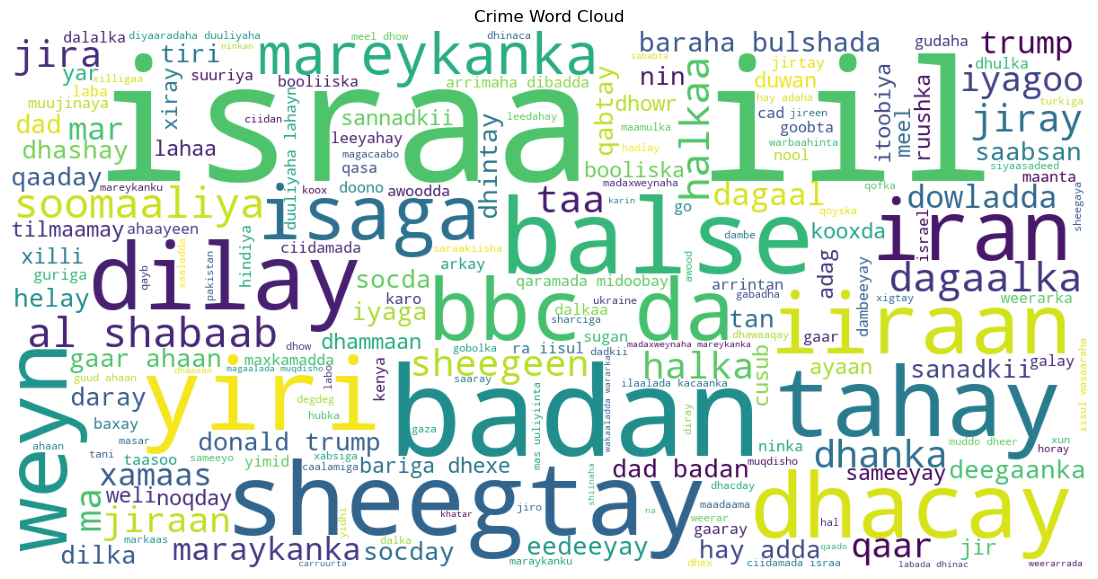

In [55]:
# =========================================================
# 33. CRIME WORD CLOUD
# =========================================================
crime_wordcloud = WordCloud(

    width=1200,
    height=600,
    background_color='white'

).generate(" ".join(crime_words))

plt.figure(figsize=(15,7))

plt.imshow(crime_wordcloud)

plt.axis("off")

plt.title("Crime Word Cloud")

plt.show()

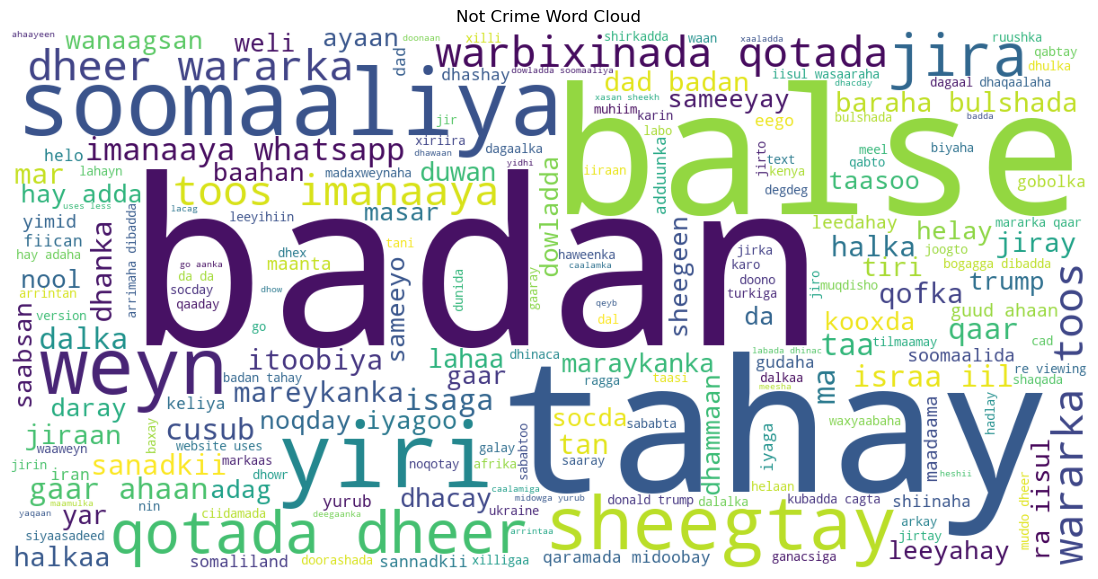

In [56]:
# =========================================================
# 34. NOT CRIME WORD CLOUD
# =========================================================
notcrime_wordcloud = WordCloud(

    width=1200,
    height=600,
    background_color='white'

).generate(" ".join(notcrime_words))

plt.figure(figsize=(15,7))

plt.imshow(notcrime_wordcloud)

plt.axis("off")

plt.title("Not Crime Word Cloud")

plt.show()
